# 💳 Credit Card Fraud Detection - 
### Problem Statement

The goal of this project is to detect fraudulent credit card transactions using machine learning techniques. Since the dataset is highly imbalanced, advanced methods like SMOTE are used to handle imbalance and improve model performance. The system aims to accurately identify fraud while minimizing false positives and enabling real-time prediction.

## 🚀 IMPORT LIBRARIES

In [93]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, roc_curve

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

## 📂 LOAD DATA

In [94]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\creditcard\creditcard.csv")

In [95]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [96]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [97]:
print('Shape Of Dataset  : ',df.shape)
print('Number  of  Rows  : ',df.shape[0])
print('Number of Columns : ',df.shape[1])

Shape Of Dataset  :  (284807, 31)
Number  of  Rows  :  284807
Number of Columns :  31


In [98]:
print('All Dataset Columns Names : \n\n',df.columns)

All Dataset Columns Names : 

 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [100]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [101]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [102]:
df.isnull().sum().sum()

0

In [103]:
print('Total Duplicates In Dataset : ',df.duplicated().sum())

Total Duplicates In Dataset :  1081


## 🧹 DATA CLEANING

In [104]:
df = df.drop_duplicates()

## 📊 DATA VISUALIZATION

In [105]:
import seaborn as sns

print("\n📊 Starting Data Visualization...")


📊 Starting Data Visualization...


### 1. Class Distribution

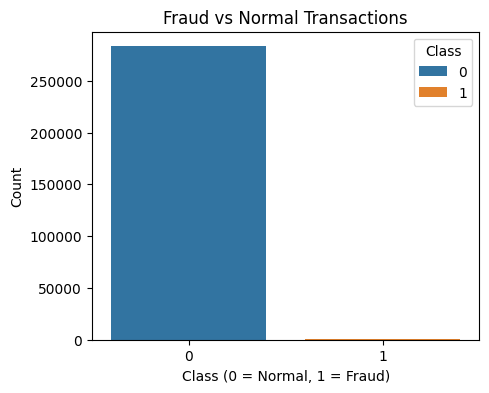

In [106]:
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df, hue='Class')
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

### 2. Percentage Distribution

In [107]:
fraud_percent = df['Class'].value_counts(normalize=True) * 100
print("\nClass Distribution (%):\n", fraud_percent)


Class Distribution (%):
 Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


### 3. Transaction Amount Distribution

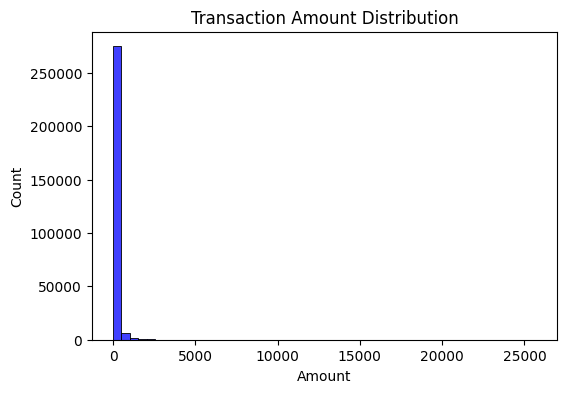

In [108]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50, color='blue')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

### 4. Fraud vs Amount

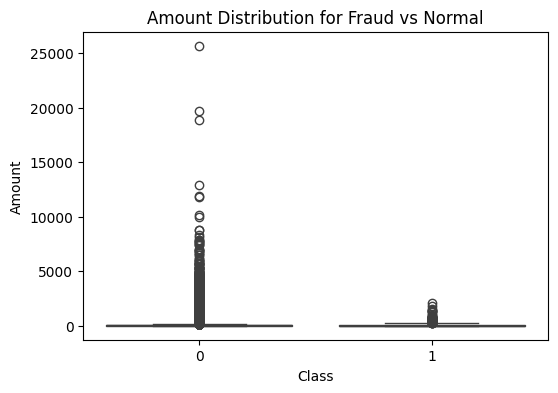

In [109]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount Distribution for Fraud vs Normal")
plt.show()

### 5. Time Distribution

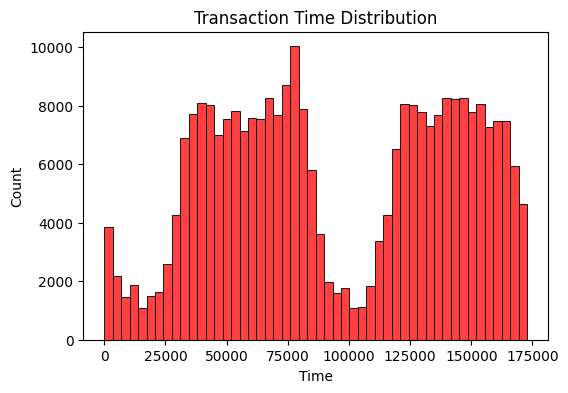

In [110]:
plt.figure(figsize=(6,4))
sns.histplot(df['Time'], bins=50, color='red')
plt.title("Transaction Time Distribution")
plt.show()

### 6. Correlation Heatmap (Important Features)

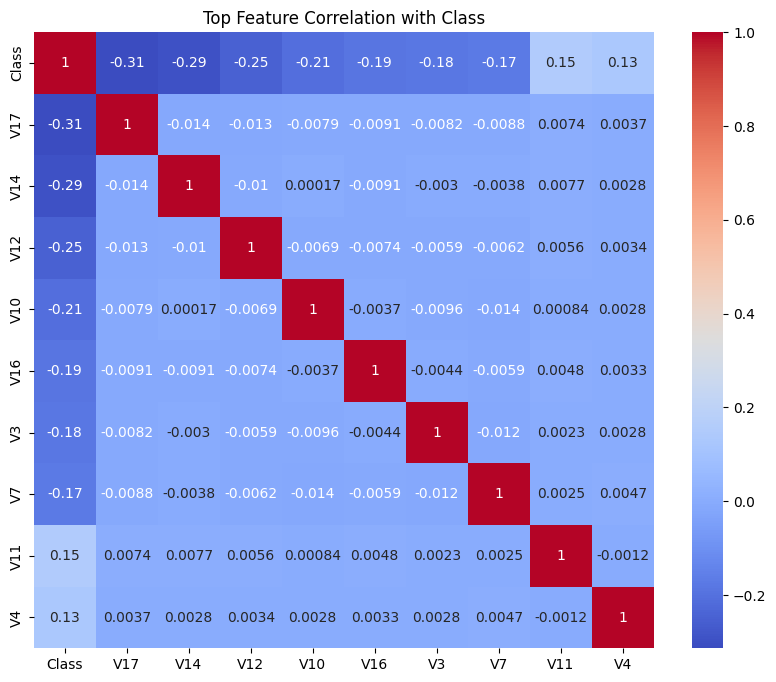

In [111]:
plt.figure(figsize=(10,8))
corr = df.corr()

# Show only top correlated features with target
top_corr = corr['Class'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlation with Class")
plt.show()

### 7. Fraud Cases Visualization

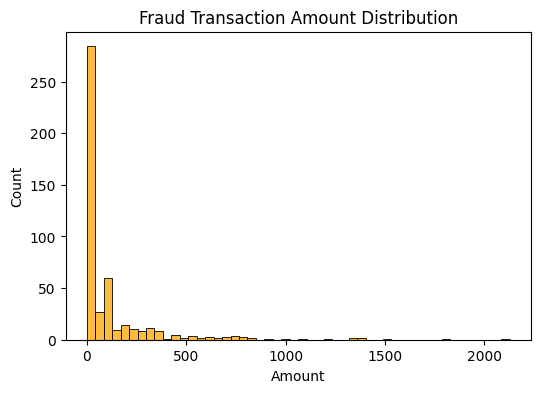

In [112]:
fraud_df = df[df['Class'] == 1]

plt.figure(figsize=(6,4))
sns.histplot(fraud_df['Amount'], bins=50, color='orange')
plt.title("Fraud Transaction Amount Distribution")
plt.show()

## SPLIT DATA

In [113]:
X = df.drop("Class", axis=1)
y = df["Class"]

## 🔀 TRAIN TEST SPLIT

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 📏 SCALING

In [115]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ⚖️ SMOTE (IMBALANCE)

In [116]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## 🔥 PARAMETER TUNING (XGBOOST)

In [117]:
xgb = XGBClassifier(eval_metric="logloss", random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_res, y_train_res)

best_model = search.best_estimator_

print("\nBest Parameters:", search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1}


## 📊 EVALUATION

In [118]:
probs = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probs)
print("\nROC-AUC:", roc_auc)


ROC-AUC: 0.9741180766075574


## 🎯 SIMPLE THRESHOLD OPTIMIZATION

In [119]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1_scores = []

for i in range(len(thresholds)):
    p = precision[i]
    r = recall[i]

    if (p + r) == 0:
        f1 = 0
    else:
        f1 = 2 * p * r / (p + r)

    f1_scores.append(f1)

best_index = f1_scores.index(max(f1_scores))
optimal_threshold = thresholds[best_index]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.9609376


## 📊 FINAL PREDICTIONS

In [120]:
final_preds = []

for prob in probs:
    if prob >= optimal_threshold:
        final_preds.append(1)
    else:
        final_preds.append(0)

print("\nClassification Report:\n")
print(classification_report(y_test, final_preds))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.74      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## 📈 ROC CURVE

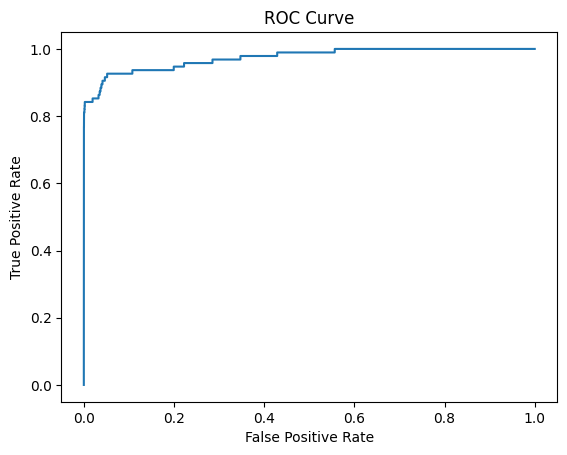

In [121]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


## 💾 SAVE MODEL

In [125]:
# joblib.dump({
#     "model": best_model,
#     "scaler": scaler,
#     "threshold": optimal_threshold
# }, "fraud_model.pkl")

# print("\n✅ Model Saved Successfully!")

In [126]:
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(optimal_threshold, "threshold.pkl")

['threshold.pkl']

In [129]:
# thresholds = [0.5, 0.7, 0.85, 0.96]

# for t in thresholds:
#     y_pred = (prob > t).astype(int)
#     print(t)
#     print(classification_report(y_test, y_pred))